Context: Based on the EDA results, Canine Glucose is typically captured every 15 mins, plus owner can manual capture anytime.

Our Goal is the predict whethere the dog is safe or unsafe in the next 1 min based on the glucose data in the last 5 mins.

For this file, we are going to process the data for the baseline model and later time-series model:
1. break down the time into each minute of the dog, generate the syntatic data based on the data and trend we have for current vs next-15-min.
2. if we have the data for the current minute, use the data from the file.
3. if there're two rows in the data at the same time, use the higher number.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load data and create dfs
canine_df = pd.read_pickle('/content/drive/MyDrive/210 Capstone/final_data/canine_df_split.pkl')
human_df  = pd.read_pickle('/content/drive/MyDrive/210 Capstone/final_data/human_df.pkl')

print("Top 5 rows of canine_df:")
display(canine_df.head())

# print("\nTop 5 rows of human_df:")
# display(human_df.head())

Top 5 rows of canine_df:


,file_identifier,timestamp,glucose,hypoglycemia,hyperglycemia,glucose_category,dt_min,roc,safe
0,canine1,2025-11-01 05:51:00,375.0,False,True,Hyperglycemia,NaN,NaN,False
1,canine1,2025-11-01 06:06:00,375.0,False,True,Hyperglycemia,15.0,0.000000,False
2,canine1,2025-11-01 06:21:00,373.0,False,True,Hyperglycemia,15.0,-0.133333,False
3,canine1,2025-11-01 06:36:00,375.0,False,True,Hyperglycemia,15.0,0.133333,False
4,canine1,2025-11-01 06:51:00,376.0,False,True,Hyperglycemia,15.0,0.066667,False


In [4]:
# Data Sanity Check
print("DataFrame Info:")
canine_df.info()

print("\nMissing values per column:")
print(canine_df.isnull().sum())

print(canine_df['glucose'].describe())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 31318 entries, 0 to 20859
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   file_identifier   31318 non-null  object        
 1   timestamp         31318 non-null  datetime64[ns]
 2   glucose           31318 non-null  float64       
 3   hypoglycemia      31318 non-null  bool          
 4   hyperglycemia     31318 non-null  bool          
 5   glucose_category  31318 non-null  object        
 6   dt_min            31308 non-null  float64       
 7   roc               30350 non-null  float64       
 8   safe              31318 non-null  bool          
dtypes: bool(3), datetime64[ns](1), float64(3), object(2)
memory usage: 1.8+ MB

Missing values per column:
file_identifier       0
timestamp             0
glucose               0
hypoglycemia          0
hyperglycemia         0
glucose_category      0
dt_min               10
roc        

# Minute-Level Canine Synthetic Data

## Create Synthetic Data at each minute

In [4]:
def build_minute_level_series_keep_observed(
    df,
    id_col="file_identifier",
    ts_col="timestamp",
    g_col="glucose",
):
    d = df.copy()

    # Ensure datetime
    d[ts_col] = pd.to_datetime(d[ts_col], errors="coerce")
    d[g_col] = pd.to_numeric(d[g_col], errors="coerce")
    d = d.dropna(subset=[id_col, ts_col])

    # Floor to minute
    d["ts_min"] = d[ts_col].dt.floor("min")

    # Keep highest glucose per minute
    d = (
        d.sort_values([id_col, "ts_min", g_col])
         .groupby([id_col, "ts_min"], as_index=False)
         .tail(1)
         .reset_index(drop=True)
    )

    # Drop original timestamp before renaming
    d = d.drop(columns=[ts_col])

    # Rename ts_min to timestamp
    d = d.rename(columns={"ts_min": ts_col})

    # Keep original glucose
    d = d[[id_col, ts_col, g_col]].rename(columns={g_col: "observed_glucose"})
    d["is_observed"] = True

    # Build full minute index per subject
    out = []
    for fid, sub in d.groupby(id_col):
        sub = sub.sort_values(ts_col).set_index(ts_col)

        full_index = pd.date_range(sub.index.min(), sub.index.max(), freq="1min")
        sub_full = sub.reindex(full_index)

        is_obs = sub_full["is_observed"].fillna(False)

        sub_full["glucose_1min"] = sub_full["observed_glucose"].interpolate(
            method="time",
            limit_area="inside"
        )

        sub_full[id_col] = fid
        sub_full["is_observed"] = is_obs

        sub_full = sub_full.reset_index().rename(columns={"index": ts_col})
        out.append(sub_full)

    minute_df = pd.concat(out, ignore_index=True)

    return minute_df[[id_col, ts_col, "observed_glucose", "glucose_1min", "is_observed"]]

# Usage:
minute_canine = build_minute_level_series_keep_observed(canine_df)

minute_canine.head(50)

/tmp/ipython-input-101629864.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  is_obs = sub_full["is_observed"].fillna(False)
/tmp/ipython-input-101629864.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  is_obs = sub_full["is_observed"].fillna(False)
/tmp/ipython-input-101629864.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  

,file_identifier,timestamp,observed_glucose,glucose_1min,is_observed
0,canine1,2025-11-01 05:51:00,375.0,375.000000,True
1,canine1,2025-11-01 05:52:00,NaN,375.000000,False
2,canine1,2025-11-01 05:53:00,NaN,375.000000,False
3,canine1,2025-11-01 05:54:00,NaN,375.000000,False
4,canine1,2025-11-01 05:55:00,NaN,375.000000,False
5,canine1,2025-11-01 05:56:00,NaN,375.000000,False
6,canine1,2025-11-01 05:57:00,NaN,375.000000,False
7,canine1,2025-11-01 05:58:00,NaN,375.000000,False
8,canine1,2025-11-01 05:59:00,NaN,375.000000,False
9,canine1,2025-11-01 06:00:00,NaN,375.000000,False


## Sanity Check

To support 1-minute horizon early-warning modeling, we expanded canine CGM records into a minute-level series via linear interpolation between observed measurements. This increased the dataset from 31,318 original records to 452,301 minute-level records (≈14.4×). Because device readings are typically captured every 15 minutes, 93.29% of minute-level rows are synthetic (interpolated) and 6.71% correspond to observed minutes (device or manual readings after de-duplication). Synthetic proportions were consistent across dogs (≈90–95%), reflecting the expected interpolation between device points.

In [5]:
# 1. Basic Structure Checks (Continuous 1-minute grid, no duplicates)
def sanity_check_structure(minute_df, fid):
    sub = minute_df[minute_df["file_identifier"] == fid].copy()
    sub = sub.sort_values("timestamp")

    print(f"\n=== STRUCTURE CHECK: {fid} ===")

    # 1) Monotonic increasing time
    print("Time monotonic:",
          sub["timestamp"].is_monotonic_increasing)

    # 2) Duplicate timestamps
    print("Duplicate timestamps:",
          sub["timestamp"].duplicated().sum())

    # 3) Check 1-minute spacing
    dt = sub["timestamp"].diff().dt.total_seconds() / 60
    print("Unique dt values:", dt.dropna().unique()[:5])
    print("Any dt != 1:", (dt.dropna() != 1).any())


# Usage
for fid in minute_canine["file_identifier"].unique():
    sanity_check_structure(minute_canine, fid)



=== STRUCTURE CHECK: canine1 ===
Time monotonic: True
Duplicate timestamps: 0
Unique dt values: [1.]
Any dt != 1: False

=== STRUCTURE CHECK: canine2 ===
Time monotonic: True
Duplicate timestamps: 0
Unique dt values: [1.]
Any dt != 1: False

=== STRUCTURE CHECK: canine31 ===
Time monotonic: True
Duplicate timestamps: 0
Unique dt values: [1.]
Any dt != 1: False

=== STRUCTURE CHECK: canine32 ===
Time monotonic: True
Duplicate timestamps: 0
Unique dt values: [1.]
Any dt != 1: False

=== STRUCTURE CHECK: canine33 ===
Time monotonic: True
Duplicate timestamps: 0
Unique dt values: [1.]
Any dt != 1: False

=== STRUCTURE CHECK: canine34 ===
Time monotonic: True
Duplicate timestamps: 0
Unique dt values: [1.]
Any dt != 1: False

=== STRUCTURE CHECK: canine4 ===
Time monotonic: True
Duplicate timestamps: 0
Unique dt values: [1.]
Any dt != 1: False

=== STRUCTURE CHECK: canine51 ===
Time monotonic: True
Duplicate timestamps: 0
Unique dt values: [1.]
Any dt != 1: False

=== STRUCTURE CHECK: canin

In [6]:
# 2. Check "Observed" vs "Original" (Ensure observed minutes match original data)

def sanity_check_observed_logic(minute_df, original_df, fid):
    sub = minute_df[minute_df["file_identifier"] == fid]
    orig = original_df[original_df["file_identifier"] == fid]

    print(f"\n=== OBSERVED CHECK: {fid} ===")

    # Count observed minutes
    print("Observed minutes:", sub["is_observed"].sum())

    # Unique original minute timestamps
    orig_minutes = orig["timestamp"].dt.floor("min").nunique()
    print("Original unique minute timestamps:", orig_minutes)

    # Should match
    print("Match count:",
          sub["is_observed"].sum() == orig_minutes)


# Usage:
for fid in minute_canine["file_identifier"].unique():
    sanity_check_observed_logic(minute_canine, canine_df, fid)



=== OBSERVED CHECK: canine1 ===
Observed minutes: 3039
Original unique minute timestamps: 3039
Match count: True

=== OBSERVED CHECK: canine2 ===
Observed minutes: 989
Original unique minute timestamps: 989
Match count: True

=== OBSERVED CHECK: canine31 ===
Observed minutes: 1965
Original unique minute timestamps: 1965
Match count: True

=== OBSERVED CHECK: canine32 ===
Observed minutes: 1041
Original unique minute timestamps: 1041
Match count: True

=== OBSERVED CHECK: canine33 ===
Observed minutes: 514
Original unique minute timestamps: 514
Match count: True

=== OBSERVED CHECK: canine34 ===
Observed minutes: 613
Original unique minute timestamps: 613
Match count: True

=== OBSERVED CHECK: canine4 ===
Observed minutes: 2447
Original unique minute timestamps: 2447
Match count: True

=== OBSERVED CHECK: canine51 ===
Observed minutes: 4104
Original unique minute timestamps: 4104
Match count: True

=== OBSERVED CHECK: canine52 ===
Observed minutes: 1714
Original unique minute timestamp

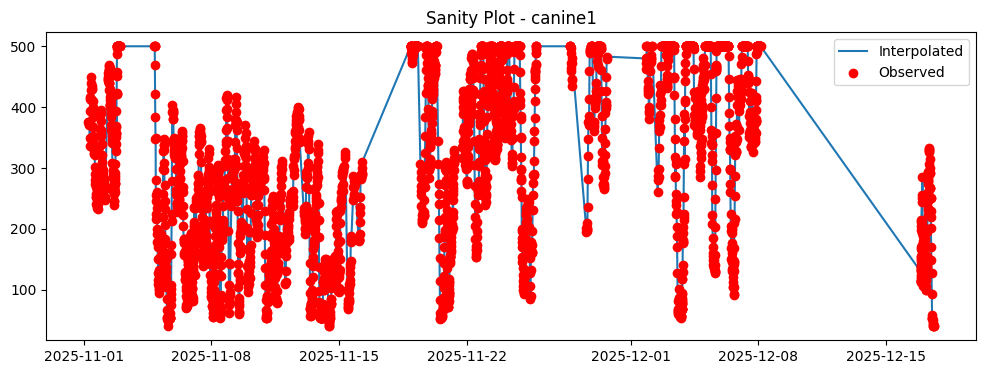

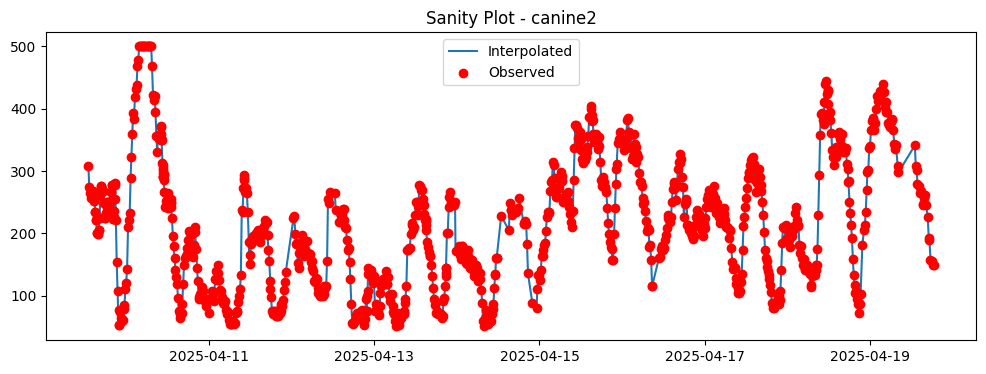

In [7]:
# 3. Visual Sanity Check

def plot_sanity(minute_df, fid):
    sub = minute_df[minute_df["file_identifier"] == fid]

    plt.figure(figsize=(12,4))
    plt.plot(sub["timestamp"], sub["glucose_1min"], label="Interpolated")

    obs = sub[sub["is_observed"]]
    plt.scatter(obs["timestamp"],
                obs["observed_glucose"],
                color="red",
                label="Observed",
                zorder=3)

    plt.title(f"Sanity Plot - {fid}")
    plt.legend()
    plt.show()

# Usage:
plot_sanity(minute_canine, "canine1")
plot_sanity(minute_canine, "canine2")

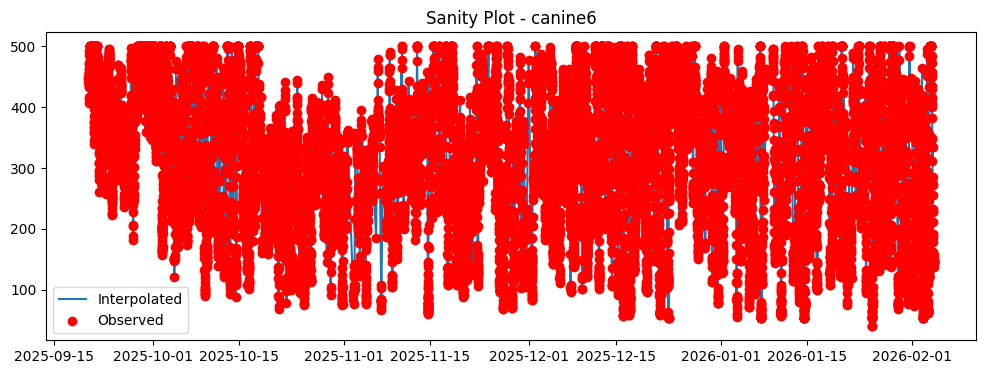

In [20]:
plot_sanity(minute_canine, "canine6")

In [8]:
# 4. NaN Check
def sanity_check_nans(minute_df, fid):
    sub = minute_df[minute_df["file_identifier"] == fid]

    print(f"\n=== NAN CHECK: {fid} ===")
    print("NaNs in glucose_1min:",
          sub["glucose_1min"].isna().sum())


for fid in minute_canine["file_identifier"].unique():
    sanity_check_nans(minute_canine, fid)



=== NAN CHECK: canine1 ===
NaNs in glucose_1min: 0

=== NAN CHECK: canine2 ===
NaNs in glucose_1min: 0

=== NAN CHECK: canine31 ===
NaNs in glucose_1min: 0

=== NAN CHECK: canine32 ===
NaNs in glucose_1min: 0

=== NAN CHECK: canine33 ===
NaNs in glucose_1min: 0

=== NAN CHECK: canine34 ===
NaNs in glucose_1min: 0

=== NAN CHECK: canine4 ===
NaNs in glucose_1min: 0

=== NAN CHECK: canine51 ===
NaNs in glucose_1min: 0

=== NAN CHECK: canine52 ===
NaNs in glucose_1min: 0

=== NAN CHECK: canine6 ===
NaNs in glucose_1min: 0


In [9]:
# 5. Overall size comparison
def compare_sizes(original_df, minute_df, label_orig="canine_df", label_min="minute_canine"):
    out = pd.DataFrame({
        "dataset": [label_orig, label_min],
        "rows": [len(original_df), len(minute_df)],
        "subjects": [original_df["file_identifier"].nunique(), minute_df["file_identifier"].nunique()],
        "start": [original_df["timestamp"].min(), minute_df["timestamp"].min()],
        "end": [original_df["timestamp"].max(), minute_df["timestamp"].max()],
    })
    out["days_span"] = (out["end"] - out["start"]).dt.total_seconds() / 86400
    return out

compare_sizes(canine_df, minute_canine)


,dataset,rows,subjects,start,end,days_span
0,canine_df,31318,10,2025-03-22 17:43:00,2026-02-04 12:57:00,318.801389
1,minute_canine,452301,10,2025-03-22 17:43:00,2026-02-04 12:57:00,318.801389


In [10]:
# 6. How many synthetic rows?
synthetic_summary = pd.DataFrame({
    "total_rows": [len(minute_canine)],
    "observed_rows": [int(minute_canine["is_observed"].sum())],
})
synthetic_summary["synthetic_rows"] = synthetic_summary["total_rows"] - synthetic_summary["observed_rows"]
synthetic_summary["synthetic_pct"] = 100 * synthetic_summary["synthetic_rows"] / synthetic_summary["total_rows"]
synthetic_summary


,total_rows,observed_rows,synthetic_rows,synthetic_pct
0,452301,30360,421941,93.287656


In [11]:
# 7. Synthetic data breakdown by dog
per_dog = (
    minute_canine
    .groupby("file_identifier")
    .agg(
        total_rows=("timestamp", "size"),
        observed_rows=("is_observed", "sum"),
        start=("timestamp", "min"),
        end=("timestamp", "max")
    )
    .reset_index()
)
per_dog["synthetic_rows"] = per_dog["total_rows"] - per_dog["observed_rows"]
per_dog["synthetic_pct"] = 100 * per_dog["synthetic_rows"] / per_dog["total_rows"]
per_dog["days_span"] = (per_dog["end"] - per_dog["start"]).dt.total_seconds() / 86400

per_dog.sort_values("synthetic_pct", ascending=False)


,file_identifier,total_rows,observed_rows,start,end,synthetic_rows,synthetic_pct,days_span
0,canine1,66818,3039,2025-11-01 05:51:00,2025-12-17 15:28:00,63779,95.451824,46.400694
5,canine34,12333,613,2025-12-02 21:53:00,2025-12-11 11:25:00,11720,95.029595,8.563889
8,canine52,30339,1714,2025-11-02 17:23:00,2025-11-23 19:01:00,28625,94.350506,21.068056
6,canine4,40332,2447,2025-03-30 13:38:00,2025-04-27 13:49:00,37885,93.932857,28.007639
1,canine2,14739,989,2025-04-09 12:56:00,2025-04-19 18:34:00,13750,93.289911,10.234722
4,canine33,7525,514,2025-05-27 18:23:00,2025-06-01 23:47:00,7011,93.169435,5.225000
9,canine6,197190,13934,2025-09-20 14:28:00,2026-02-04 12:57:00,183256,92.933719,136.936806
3,canine32,14194,1041,2025-05-11 09:24:00,2025-05-21 05:57:00,13153,92.665915,9.856250
7,canine51,49332,4104,2025-03-22 17:43:00,2025-04-25 23:54:00,45228,91.680856,34.257639
2,canine31,19499,1965,2025-04-12 19:03:00,2025-04-26 08:01:00,17534,89.922560,13.540278


In [12]:
# 8. Compare “how much minute expansion happened” per dog
orig_counts = (
    canine_df.groupby("file_identifier")
    .size()
    .reset_index(name="orig_rows")
)

minute_counts = (
    minute_canine.groupby("file_identifier")
    .size()
    .reset_index(name="minute_rows")
)

compare_per_dog = orig_counts.merge(minute_counts, on="file_identifier", how="outer").fillna(0)
compare_per_dog["expansion_factor"] = compare_per_dog["minute_rows"] / compare_per_dog["orig_rows"].replace(0, np.nan)

compare_per_dog.sort_values("expansion_factor", ascending=False)


,file_identifier,orig_rows,minute_rows,expansion_factor
0,canine1,3104,66818,21.526418
5,canine34,625,12333,19.732800
8,canine52,1748,30339,17.356407
6,canine4,2470,40332,16.328745
1,canine2,1009,14739,14.607532
4,canine33,538,7525,13.986989
9,canine6,14277,197190,13.811725
3,canine32,1106,14194,12.833635
7,canine51,4248,49332,11.612994
2,canine31,2193,19499,8.891473


In [13]:
# 9. Real Change vs Flat Interpolation: what % of minutes are almost unchanged
# If interpolation is linear, consecutive minutes will often have very tiny changes.

tmp = minute_canine.sort_values(["file_identifier","timestamp"]).copy()
tmp["delta_1min"] = tmp.groupby("file_identifier")["glucose_1min"].diff()

(tmp["delta_1min"].abs() < 0.1).mean() * 100


np.float64(24.97208717203809)

# Add Noise to Synthetic Data

In [23]:
def add_bridge_noise_safe(minute_df, sigma=1.2, seed=42,
                          value_col="glucose_1min",
                          observed_col="observed_glucose",
                          is_observed_col="is_observed",
                          clip_range=(40, 500)):
    """
    Add Brownian-bridge noise between observed points, safely (no index misalignment).

    Inputs expected in minute_df:
      - file_identifier
      - timestamp
      - glucose_1min (minute-level interpolated series)
      - is_observed (True at observed minutes)
      - observed_glucose (original glucose at observed minutes; NaN elsewhere)

    Output:
      - glucose_1min_noisy column

    Notes:
      - Noise is 0 at segment endpoints (observed minutes) by construction.
      - If clip_range is not None, clamps noisy values to a plausible range.
    """
    rng = np.random.default_rng(seed)
    d = minute_df.sort_values(["file_identifier", "timestamp"]).copy()

    # start from the clean interpolated series
    d["glucose_1min_noisy"] = pd.to_numeric(d[value_col], errors="coerce")

    # safety: ensure boolean
    if d[is_observed_col].dtype != bool:
        d[is_observed_col] = d[is_observed_col].astype(bool)

    for fid, sub in d.groupby("file_identifier", sort=False):
        sub = sub.sort_values("timestamp")
        idx = sub.index  # original indices in d, safe for write-back

        g = sub["glucose_1min_noisy"].to_numpy(dtype=float, copy=True)
        is_obs = sub[is_observed_col].to_numpy()

        obs_pos = np.flatnonzero(is_obs)

        # If fewer than 2 observed points, nothing to bridge
        if len(obs_pos) < 2:
            continue

        for i in range(len(obs_pos) - 1):
            a = obs_pos[i]
            b = obs_pos[i + 1]
            n = b - a + 1

            # need at least one interior minute
            if n <= 2:
                continue

            # Brownian bridge noise sequence of length n with endpoints 0
            eps = rng.normal(0, 1, size=n)
            w = np.cumsum(eps)
            t = np.arange(n)
            bridge = w - (t / (n - 1)) * w[-1]  # bridge[0]=0, bridge[-1]=0

            # scale bridge interior to sigma
            interior = bridge[1:-1]
            s = np.std(interior)
            if s > 0:
                bridge = bridge * (sigma / s)
            else:
                bridge[:] = 0.0

            # apply only to interior points
            g[a + 1:b] = g[a + 1:b] + bridge[1:-1]

        # Optional: keep observed minutes exactly equal to observed_glucose (extra guardrail)
        # This is helpful if value_col might not perfectly match observed points.
        if observed_col in sub.columns:
            obs_vals = sub[observed_col].to_numpy(dtype=float)
            g[is_obs & ~np.isnan(obs_vals)] = obs_vals[is_obs & ~np.isnan(obs_vals)]

        # Optional: clamp to plausible range
        if clip_range is not None:
            g = np.clip(g, clip_range[0], clip_range[1])

        # write back safely using original indices
        d.loc[idx, "glucose_1min_noisy"] = g

    return d


In [24]:
minute_canine_noisy = add_bridge_noise_safe(minute_canine, sigma=1.2, seed=42, clip_range=(40, 500))

minute_canine_noisy.head(10)

,file_identifier,timestamp,observed_glucose,glucose_1min,is_observed,glucose_1min_noisy
0,canine1,2025-11-01 05:51:00,375.0,375.0,True,375.000000
1,canine1,2025-11-01 05:52:00,NaN,375.0,False,374.300250
2,canine1,2025-11-01 05:53:00,NaN,375.0,False,375.139635
3,canine1,2025-11-01 05:54:00,NaN,375.0,False,376.175969
4,canine1,2025-11-01 05:55:00,NaN,375.0,False,374.216739
5,canine1,2025-11-01 05:56:00,NaN,375.0,False,372.929693
6,canine1,2025-11-01 05:57:00,NaN,375.0,False,373.124082
7,canine1,2025-11-01 05:58:00,NaN,375.0,False,372.858422
8,canine1,2025-11-01 05:59:00,NaN,375.0,False,372.902969
9,canine1,2025-11-01 06:00:00,NaN,375.0,False,372.081208


In [25]:
minute_canine_noisy.groupby("file_identifier")["glucose_1min_noisy"].agg(["min","max","median","mean","std"])


,min,max,median,mean,std
file_identifier,,,,,
canine1,40.000000,500.0,345.412315,335.887112,134.776675
canine2,49.841621,500.0,208.430994,213.234727,101.067414
canine31,40.000000,500.0,122.601237,167.340772,92.505435
canine32,107.000000,500.0,415.551563,386.096899,108.326327
canine33,144.244008,500.0,455.326401,423.807047,82.060869
canine34,55.000000,500.0,390.613384,352.921651,137.440125
canine4,67.000000,441.0,188.077612,192.819673,53.834678
canine51,40.000000,500.0,382.879718,359.162333,121.997652
canine52,56.424151,500.0,376.037357,373.294911,90.805297


In [26]:
def delta_stats(df, col="glucose_1min_noisy"):
    tmp = df.sort_values(["file_identifier","timestamp"]).copy()
    tmp["delta_1min"] = tmp.groupby("file_identifier")[col].diff()
    return tmp["delta_1min"].abs().describe(percentiles=[.5,.9,.95,.99])

for s in [1.0, 1.2, 1.5]:
    noisy = add_bridge_noise_safe(minute_canine, sigma=s, seed=42, clip_range=(40, 500))
    print(f"\n=== sigma={s} ===")
    print(delta_stats(noisy, col="glucose_1min_noisy"))



=== sigma=1.0 ===
count    452291.000000
mean          1.071976
std           1.915376
min           0.000000
50%           0.693125
90%           2.469796
95%           3.244697
99%           5.660377
max         460.000000
Name: delta_1min, dtype: float64

=== sigma=1.2 ===
count    452291.000000
mean          1.155510
std           1.993245
min           0.000000
50%           0.759948
90%           2.665960
95%           3.470206
99%           5.906492
max         460.000000
Name: delta_1min, dtype: float64

=== sigma=1.5 ===
count    452291.000000
mean          1.291234
std           2.130988
min           0.000000
50%           0.862142
90%           3.000000
95%           3.855150
99%           6.247023
max         460.000000
Name: delta_1min, dtype: float64


## Sanity Check and Comparison

In [28]:
tmp = minute_canine_noisy.sort_values(["file_identifier","timestamp"]).copy()
tmp["delta_1min"] = tmp.groupby("file_identifier")["glucose_1min_noisy"].diff().abs()

tmp["delta_1min"].describe(percentiles=[.5,.9,.95,.99])


,delta_1min
count,452291.000000
mean,1.155510
std,1.993245
min,0.000000
50%,0.759948
90%,2.665960
95%,3.470206
99%,5.906492
max,460.000000


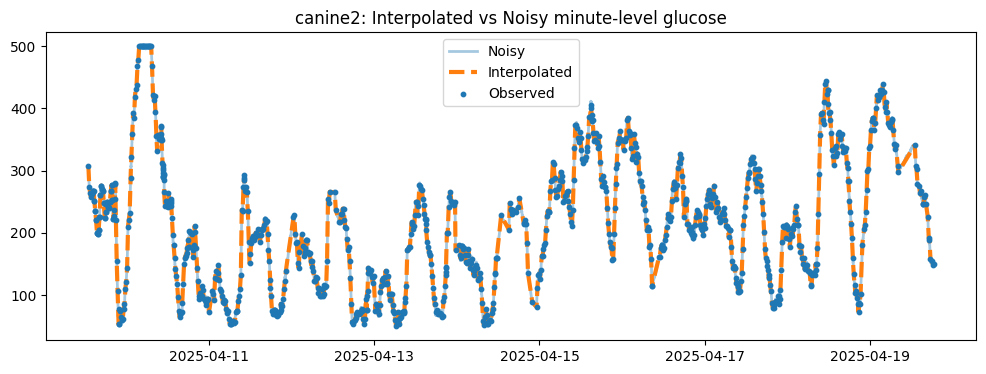

In [39]:
fid = "canine2"
sub = minute_canine_noisy[minute_canine_noisy["file_identifier"] == fid].copy()

# sort by time
sub["timestamp"] = pd.to_datetime(sub["timestamp"])
sub = sub.sort_values("timestamp")

plt.figure(figsize=(12,4))

# Plot noisy first, lighter, so interpolated can sit on top
plt.plot(sub["timestamp"], sub["glucose_1min_noisy"],
         label="Noisy", alpha=0.4, linewidth=2)

# Plot interpolated on top with dashed line + higher zorder
plt.plot(sub["timestamp"], sub["glucose_1min"],
         label="Interpolated", linewidth=3, linestyle="--", zorder=3)

# Observed points
obs = sub[sub["is_observed"]]
plt.scatter(obs["timestamp"], obs["observed_glucose"],
            s=10, label="Observed", zorder=4)

plt.title(f"{fid}: Interpolated vs Noisy minute-level glucose")
plt.legend()
plt.show()

In [32]:
summary = (
    minute_canine_noisy
    .groupby("file_identifier")
    .agg(
        g1min_min=("glucose_1min", "min"),
        g1min_max=("glucose_1min", "max"),
        g1min_median=("glucose_1min", "median"),
        g1min_mean=("glucose_1min", "mean"),
        g1min_std=("glucose_1min", "std"),

        noisy_min=("glucose_1min_noisy", "min"),
        noisy_max=("glucose_1min_noisy", "max"),
        noisy_median=("glucose_1min_noisy", "median"),
        noisy_mean=("glucose_1min_noisy", "mean"),
        noisy_std=("glucose_1min_noisy", "std"),
    )
    .reset_index()
)

summary


,file_identifier,g1min_min,g1min_max,g1min_median,g1min_mean,g1min_std,noisy_min,noisy_max,noisy_median,noisy_mean,noisy_std
0,canine1,40.0,500.0,346.066667,336.349330,134.720704,40.000000,500.0,345.412315,335.887112,134.776675
1,canine2,51.0,500.0,208.237037,213.208596,101.004060,49.841621,500.0,208.430994,213.234727,101.067414
2,canine31,54.0,500.0,122.800000,167.146161,92.692528,40.000000,500.0,122.601237,167.340772,92.505435
3,canine32,107.0,500.0,415.533333,386.143758,108.313587,107.000000,500.0,415.551563,386.096899,108.326327
4,canine33,145.0,500.0,454.666667,423.669568,82.279432,144.244008,500.0,455.326401,423.807047,82.060869
5,canine34,55.0,500.0,390.333333,353.050312,137.683782,55.000000,500.0,390.613384,352.921651,137.440125
6,canine4,67.0,441.0,188.000000,192.760922,53.804982,67.000000,441.0,188.077612,192.819673,53.834678
7,canine51,56.0,500.0,382.828571,359.265487,122.059726,40.000000,500.0,382.879718,359.162333,121.997652
8,canine52,58.0,500.0,376.109890,373.125334,90.926125,56.424151,500.0,376.037357,373.294911,90.805297
9,canine6,40.0,500.0,327.308830,321.126449,108.084746,40.000000,500.0,327.458317,321.123982,108.023778


# Labeling for final dataset

In [40]:
import pandas as pd
import numpy as np

def align_minute_canine_schema(
    minute_canine,
    hypo_threshold=70,
    hyper_threshold=180,
    horizon_min=5
):
    d = minute_canine.copy()

    # 1) Core columns + types
    d["timestamp"] = pd.to_datetime(d["timestamp"], errors="coerce")
    d["glucose"] = pd.to_numeric(d["glucose_1min"], errors="coerce")
    d = d.dropna(subset=["file_identifier", "timestamp"]).sort_values(["file_identifier", "timestamp"])

    # 2) dt_min and roc (per dog)
    d["dt_min"] = (
        d.groupby("file_identifier")["timestamp"]
         .diff()
         .dt.total_seconds() / 60.0
    )
    d["roc"] = d.groupby("file_identifier")["glucose"].diff() / d["dt_min"]
    d["roc"] = d["roc"].replace([np.inf, -np.inf], np.nan)

    # 3) Glucose category + hypo/hyper flags
    d["hypoglycemia"] = d["glucose"] < hypo_threshold
    d["hyperglycemia"] = d["glucose"] > hyper_threshold

    d["glucose_category"] = np.select(
        [d["hypoglycemia"], d["hyperglycemia"]],
        ["Hypoglycemia", "Hyperglycemia"],
        default="Normal"
    )

    # 4) safe / unsafe flags
    d["safe"] = d["glucose_category"] == "Normal"
    d["unsafe"] = ~d["safe"]

    # 5) Label: unsafe within next H minutes (per dog)
    # "Any time in the next H minutes has unsafe" => True, else False
    out = []
    for fid, sub in d.groupby("file_identifier", sort=False):
        sub = sub.sort_values("timestamp").set_index("timestamp")

        # Reverse time so "future H" becomes "past H" rolling
        sub_rev = sub.iloc[::-1]
        future_unsafe = (
            sub_rev["unsafe"]
            .rolling(f"{horizon_min}min", closed="right")  # (t, t+H]
            .max()
            .iloc[::-1]
            .fillna(False)
            .astype(bool)
        )

        sub["unsafe_next_5min"] = future_unsafe  # name requested
        out.append(sub.reset_index())

    d = pd.concat(out, ignore_index=True).sort_values(["file_identifier", "timestamp"])

    # 6) Keep only aligned columns (plus unsafe_next_5min)
    aligned = d[[
        "file_identifier", "timestamp", "glucose",
        "hypoglycemia", "hyperglycemia", "glucose_category",
        "dt_min", "roc", "safe", "unsafe_next_5min"
    ]].copy()

    return aligned


# Usage:
minute_canine_final = align_minute_canine_schema(
    minute_canine,
    hypo_threshold=65,
    hyper_threshold=250,
    horizon_min=5
)

minute_canine_final.head()


,file_identifier,timestamp,glucose,hypoglycemia,hyperglycemia,glucose_category,dt_min,roc,safe,unsafe_next_5min
0,canine1,2025-11-01 05:51:00,375.0,False,True,Hyperglycemia,NaN,NaN,False,True
1,canine1,2025-11-01 05:52:00,375.0,False,True,Hyperglycemia,1.0,0.0,False,True
2,canine1,2025-11-01 05:53:00,375.0,False,True,Hyperglycemia,1.0,0.0,False,True
3,canine1,2025-11-01 05:54:00,375.0,False,True,Hyperglycemia,1.0,0.0,False,True
4,canine1,2025-11-01 05:55:00,375.0,False,True,Hyperglycemia,1.0,0.0,False,True


In [41]:
# Sanity Check
minute_canine_final[["dt_min","roc"]].describe()
minute_canine_final["glucose_category"].value_counts(dropna=False)
minute_canine_final["safe"].value_counts(dropna=False)


,count
safe,
False,301987
True,150314


In [42]:
minute_canine_final.head(50)

,file_identifier,timestamp,glucose,hypoglycemia,hyperglycemia,glucose_category,dt_min,roc,safe,unsafe_next_5min
0,canine1,2025-11-01 05:51:00,375.000000,False,True,Hyperglycemia,NaN,NaN,False,True
1,canine1,2025-11-01 05:52:00,375.000000,False,True,Hyperglycemia,1.0,0.000000,False,True
2,canine1,2025-11-01 05:53:00,375.000000,False,True,Hyperglycemia,1.0,0.000000,False,True
3,canine1,2025-11-01 05:54:00,375.000000,False,True,Hyperglycemia,1.0,0.000000,False,True
4,canine1,2025-11-01 05:55:00,375.000000,False,True,Hyperglycemia,1.0,0.000000,False,True
5,canine1,2025-11-01 05:56:00,375.000000,False,True,Hyperglycemia,1.0,0.000000,False,True
6,canine1,2025-11-01 05:57:00,375.000000,False,True,Hyperglycemia,1.0,0.000000,False,True
7,canine1,2025-11-01 05:58:00,375.000000,False,True,Hyperglycemia,1.0,0.000000,False,True
8,canine1,2025-11-01 05:59:00,375.000000,False,True,Hyperglycemia,1.0,0.000000,False,True
9,canine1,2025-11-01 06:00:00,375.000000,False,True,Hyperglycemia,1.0,0.000000,False,True


## Export Data

In [43]:
# Export final data
# target directory
out_dir = "/content/drive/MyDrive/210 Capstone/final_data"

# export dataframes to csv
minute_canine_final.to_csv(os.path.join(out_dir, "minute_canine_final.csv"), index=False)

print("Files exported to:", out_dir)

# export dataframes to pkl
minute_canine_final.to_pickle(os.path.join(out_dir, "minute_canine_final.pkl"))

print("PKL files saved to:", out_dir)


Files exported to: /content/drive/MyDrive/210 Capstone/final_data
PKL files saved to: /content/drive/MyDrive/210 Capstone/final_data
